# Modelo de predicción de *silent churn* — Glamour Perú

**Dataset**: v5 · **Granularidad**: (vendedora, mes calendario) · **Horizonte**: 6 meses
**Modelo**: `HistGradientBoostingClassifier` con `class_weight='balanced'` (hiperparámetros tuneados con Optuna)

Este notebook aplica la mejor configuración encontrada en la fase exploratoria
(notebooks 01–08 en `drafts/`) y la presenta como entregable autocontenido. El
camino que llevó hasta acá está documentado en `VERSIONES.md`; este documento
sólo aplica las decisiones y reporta resultados.

Cada bloque va precedido por una explicación corta del **qué** y el **por qué**
para que un lector sin formación profunda en ML pueda seguirlo.


# 1. Marco teórico

## 1.1 Silent churn

En venta directa **no hay baja formal**: una vendedora simplemente deja de
hacer pedidos. Eso se llama *silent churn*. La definición operativa que
usamos es:

> **Una vendedora churnea en el mes _M_ si no compra en ninguno de los
> 6 meses calendario siguientes (_M+1_ … _M+6_).**

El número 6 se justifica empíricamente en la Sección 3 — no es arbitrario.

## 1.2 Aprendizaje supervisado y panel longitudinal

- **Entrada (X)**: características de una vendedora en un mes dado (RFM:
  recencia, frecuencia, monetario; tendencias; diversidad de producto;
  contexto geográfico).
- **Salida (y)**: 0 = no churnea en los próximos 6 meses; 1 = churnea.
- **Granularidad**: una fila por **(vendedora, mes)** — un *panel longitudinal*.
  Una vendedora con 18 meses de historia activa aporta 18 filas.

El modelo devuelve **P(churn=1) ∈ [0, 1]**. La decisión binaria depende de
un **threshold** que se elige según el costo de cada tipo de error
(Sección 7).

## 1.3 Validación: dos protocolos complementarios

| Protocolo | Pregunta que responde | Cómo se hace |
|---|---|---|
| **GroupKFold por vendedora** (5 folds) | ¿Generaliza a vendedoras nuevas? | Cada vendedora cae entera en train o entera en test, nunca en los dos. |
| **Split temporal forward** | ¿Predice el futuro a partir del pasado? | Train = meses anteriores, test = últimos 6 meses, GAP de 7 meses entre ambos para evitar solapamiento del horizonte. |

Reportamos los dos: GroupKFold es la métrica honesta de generalización;
split forward simula producción.

## 1.4 Métricas

- **AUC ROC**: ¿con qué probabilidad el modelo le asigna mayor score a un
  churner que a un no-churner tomados al azar? Independiente del threshold.
- **PR-AUC**: lo relevante es el **lift sobre la prevalencia**. PR-AUC 0.50
  con prevalencia 0.275 → lift ≈ 1.83×.
- **Precision / Recall / F1**: una vez fijado un threshold, miden la calidad
  de la decisión 0/1.

## 1.5 Anti-leakage

Tres trampas resueltas: (1) variables del horizonte como features —
eliminadas desde v3; (2) misma vendedora en train y test — resuelto con
`GroupKFold` por `id_vendedor`; (3) solapamiento de horizonte en split
temporal — resuelto con GAP = 7 meses.


# 2. Carga del dataset v5

El dataset vive en BigQuery (`glamour-peru-dw.glamour_dw.training_churn_v5`)
y se construye con `data/qry_churn_v5.sql`. La query ya aplica los filtros
de población (`compras_historicas >= 3`, churn no nulo, mes con compra).


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v5`'
RANDOM_STATE = 42
N_SPLITS = 5
HORIZON_CHURN = 6
TEST_WINDOW = 6
GAP = HORIZON_CHURN + 1   # = 7

bq = bigquery.Client(project=PROJECT)


In [2]:
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

print(f'Filas              : {len(df):,}')
print(f'Vendedoras únicas  : {df["id_vendedor"].nunique():,}')
print(f'Meses cubiertos    : {df["mes_obs"].nunique()}')
print(f'Rango temporal     : {df["mes_obs"].min()} → {df["mes_obs"].max()}')
print(f'Tasa de churn      : {df["churn"].mean():.4f}  ({df["churn"].sum():,} positivos)')


Filas              : 23,684
Vendedoras únicas  : 4,211
Meses cubiertos    : 106
Rango temporal     : 2017-01-01 → 2025-10-01
Tasa de churn      : 0.2750  (6,514 positivos)


# 3. ¿Por qué 6 meses de horizonte?

El target depende críticamente de **cuántos meses de silencio consideramos
suficiente para llamar a alguien "churner"**. Si elegimos un k chico (3
meses) marcamos como churn a vendedoras esporádicas legítimas que vuelven.
Si elegimos un k grande (12 meses) la señal llega tarde para cualquier
acción de retención.

Esta sección reproduce el análisis de `notebooks/drafts/06_horizonte_v4.ipynb`
de forma compacta para mostrar **por qué el codo está en k = 6**.

## 3.1 Construcción del panel de eventos

Necesitamos los **gaps reales entre compras consecutivas**, sin el filtro
`churn IS NOT NULL` del dataset v5 (que ya elimina los meses de cola con
horizonte futuro insuficiente). Por eso vamos directo a `fact_pedidos`.


In [3]:
BLACKLIST = (20102, 20201, 23105)   # COVID, fechas invertidas, curso no-retail

QUERY_EVENTS = f"""
WITH
  rango_fechas AS (
    SELECT
      DATE_TRUNC(MIN(d.date), MONTH) AS primer_mes,
      DATE_TRUNC(MAX(d.date), MONTH) AS ultimo_mes
    FROM `{PROJECT}.{DATASET}.fact_pedidos` p
    JOIN `{PROJECT}.{DATASET}.dim_fecha` d ON p.id_fecha = d.id_fecha
  ),
  meses_ordenados AS (
    SELECT mes, ROW_NUMBER() OVER (ORDER BY mes) AS mes_rank
    FROM rango_fechas,
    UNNEST(GENERATE_DATE_ARRAY(primer_mes, ultimo_mes, INTERVAL 1 MONTH)) AS mes
  ),
  pedidos_limpios AS (
    SELECT p.id_vendedor, DATE_TRUNC(d.date, MONTH) AS mes
    FROM `{PROJECT}.{DATASET}.fact_pedidos` p
    JOIN `{PROJECT}.{DATASET}.dim_fecha` d ON p.id_fecha = d.id_fecha
    WHERE p.id_campana NOT IN {BLACKLIST}
  )
SELECT DISTINCT pl.id_vendedor, pl.mes, m.mes_rank
FROM pedidos_limpios pl
JOIN meses_ordenados m ON pl.mes = m.mes
ORDER BY pl.id_vendedor, m.mes_rank
"""

events = bq.query(QUERY_EVENTS).to_dataframe()
events['mes'] = pd.to_datetime(events['mes'])
events['cum_purchases']      = events.groupby('id_vendedor').cumcount() + 1
events['next_rank']          = events.groupby('id_vendedor')['mes_rank'].shift(-1)
events['gap_to_next']        = events['next_rank'] - events['mes_rank']
LAST_RANK = int(events['mes_rank'].max())
events['observable_horizon'] = LAST_RANK - events['mes_rank']

# Mismo filtro de población que el dataset v5
events_h3 = events[events['cum_purchases'] >= 3]
print(f'Eventos (vendedora, mes con compra): {len(events):,}')
print(f'Tras filtro cum_purchases >= 3     : {len(events_h3):,}')
print(f'Vendedoras                         : {events_h3["id_vendedor"].nunique():,}')


Eventos (vendedora, mes con compra): 43,118
Tras filtro cum_purchases >= 3     : 24,885
Vendedoras                         : 4,288


## 3.2 Curva *silent* y *hazard* de retorno

Calculamos dos curvas sobre la **sub-muestra fully-observable** (eventos
con al menos 12 meses de futuro disponibles, para que las dos curvas no
estén sesgadas por censura):

1. **Curva silent**: `pct_silent(k)` = fracción de eventos cuyo gap a la
   próxima compra es **mayor que k meses** (o nunca vuelve). Es la
   tasa de churn que se obtendría si el horizonte fuera k.
2. **Hazard de retorno en k**: probabilidad condicional de **comprar
   exactamente en t+k** dado que estuvo silenciosa hasta t+k-1. Cuanto
   más alto el hazard, más vendedoras "siguen vivas" — todavía hay
   recuperación genuina. Cuando el hazard cae a niveles bajos y se
   estabiliza, llamar churn a esa cola es razonable.


In [4]:
MAX_K = 12
fully_obs = events_h3[events_h3['observable_horizon'] >= MAX_K].copy()

rows = []
for k in range(1, MAX_K + 1):
    silent = (fully_obs['gap_to_next'].isna() | (fully_obs['gap_to_next'] > k)).mean()
    rows.append({'k': k, 'pct_silent': silent})
horizon_curve = pd.DataFrame(rows)

# hazard(k) = (silent(k-1) - silent(k)) / silent(k-1)
horizon_curve['hazard'] = (
    -horizon_curve['pct_silent'].diff().fillna(1 - horizon_curve['pct_silent'].iloc[0])
    / horizon_curve['pct_silent'].shift(1).fillna(1.0)
)
# Δ tasa = cuánto cae la tasa de churn al pasar de k-1 a k
horizon_curve['delta_silent_pp'] = -horizon_curve['pct_silent'].diff() * 100

print(f'Sub-muestra fully-observable (>= {MAX_K} meses futuros): {len(fully_obs):,}')
print()
print(horizon_curve.round(4).to_string(index=False))


Sub-muestra fully-observable (>= 12 meses futuros): 22,642

 k  pct_silent  hazard  delta_silent_pp
 1      0.5863 -0.4137              NaN
 2      0.4386  0.2519          14.7690
 3      0.3682  0.1605           7.0400
 4      0.3264  0.1136           4.1825
 5      0.2978  0.0876           2.8575
 6      0.2761  0.0730           2.1730
 7      0.2599  0.0586           1.6165
 8      0.2449  0.0576           1.4972
 9      0.2335  0.0465           1.1395
10      0.2254  0.0350           0.8171
11      0.2165  0.0392           0.8833
12      0.2090  0.0347           0.7508


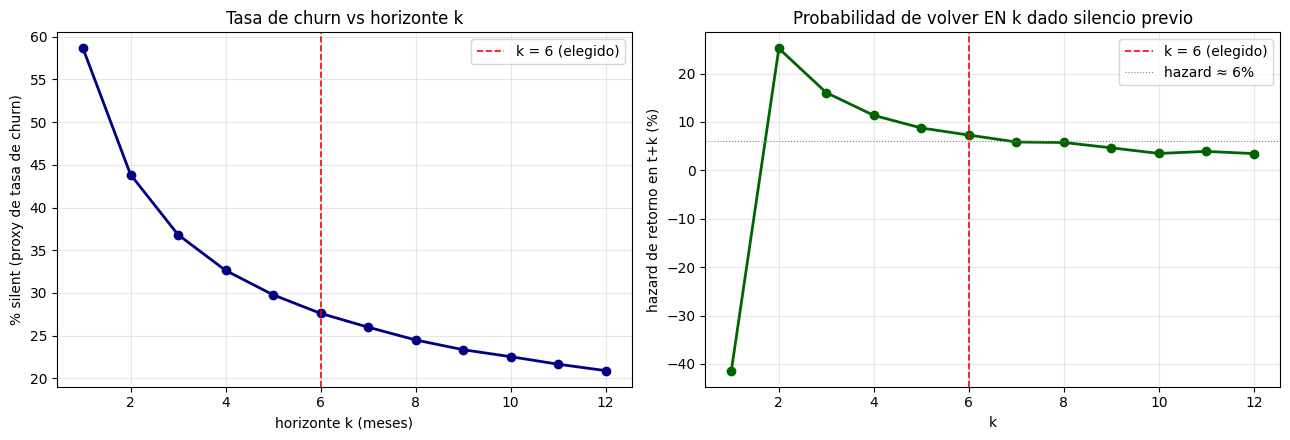

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(horizon_curve['k'], horizon_curve['pct_silent'] * 100,
           marker='o', color='navy', lw=2)
ax[0].axvline(6, ls='--', color='red', lw=1.2, label='k = 6 (elegido)')
ax[0].set_xlabel('horizonte k (meses)')
ax[0].set_ylabel('% silent (proxy de tasa de churn)')
ax[0].set_title('Tasa de churn vs horizonte k')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(horizon_curve['k'], horizon_curve['hazard'] * 100,
           marker='o', color='darkgreen', lw=2)
ax[1].axvline(6, ls='--', color='red', lw=1.2, label='k = 6 (elegido)')
ax[1].axhline(6, ls=':', color='gray', lw=0.8, label='hazard ≈ 6%')
ax[1].set_xlabel('k')
ax[1].set_ylabel('hazard de retorno en t+k (%)')
ax[1].set_title('Probabilidad de volver EN k dado silencio previo')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 3.3 Lectura del codo

Lo que hay que mirar son los dos signos clásicos de **convergencia**:

1. **La curva silent se aplana**: la caída marginal de la tasa de churn
   al sumar un mes de espera (`delta_silent_pp`) se vuelve chica. Pasar
   de k=5 a k=6 todavía recupera vendedoras esporádicas; pasar de k=6 a
   k=7 ya casi no cambia la tasa.
2. **El hazard se estabiliza por debajo del 6%**: a partir de k=6, una
   vendedora que estuvo callada los 6 meses anteriores tiene menos del
   6% de probabilidad de volver en el mes siguiente. Esa cola larga es
   ruido, no recuperación real.

**Conclusión**: k = 6 es el primer valor donde se cumplen ambas
condiciones simultáneamente. Es el punto donde **se atrapa la mayor
parte del churn real sin inflar falsos positivos** con vendedoras
esporádicas que vuelven al mes 4 o 5.

> **Nota histórica**: en el dataset v3 (granularidad por campaña) ya se
> había elegido k = 6 *campañas*. La migración a granularidad mensual
> (v4 → v5) reabrió la pregunta. El análisis acá replica el de
> `06_horizonte_v4.ipynb` y confirma que **6 meses** sigue siendo la
> elección correcta en el régimen mensual.

A partir de acá todo el resto del notebook trabaja con `HORIZON_CHURN = 6`.


# 4. Preparación de features

Excluimos columnas que no deben entrar al modelo (identificadores,
trazabilidad temporal, features removidas por el ablation):

| Columna | Razón |
|---|---|
| `id_vendedor` | Identificador → memorización. |
| `mes_obs`, `mes_rank_obs` | Trazabilidad, no feature. |
| `fecha_ingreso` | Su señal está en `antiguedad_meses`. |
| `id_coordinadora`, `ccodrelacion` | IDs de alta cardinalidad. |
| `ccodubigeo`, `distrito` | Cardinalidad ~cientos → usamos `provincia`/`departamento`. |
| `mes_num`, `anio_mes_num` | Sacadas tras el ablation (ver `ablation_temporal_v5.ipynb`): en split forward el modelo es igual o mejor sin ellas, y `anio_mes_num` extrapolaría en producción. |
| `churn` | Target. |


In [6]:
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs', 'fecha_ingreso',
    'id_coordinadora', 'ccodrelacion', 'ccodubigeo', 'distrito',
    'mes_num', 'anio_mes_num',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'Features totales : {len(feature_cols)}  (numéricas: {len(numeric_cols)}, categóricas: {len(CATEGORICAL)})')
print(f'Target           : no-churn {(y==0).sum():,} ({(y==0).mean()*100:.1f}%) · churn {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')


Features totales : 39  (numéricas: 35, categóricas: 4)
Target           : no-churn 17,170 (72.5%) · churn 6,514 (27.5%)


**Pipeline de preprocesamiento**: imputación + one-hot. Se aplica idéntico
en train y test para no introducir distribuciones distintas en los dos
lados.


In [7]:
def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])

X_tx = build_preprocessor().fit_transform(X.head(100))
print(f'Pipeline OK: {X.head(100).shape} → {X_tx.shape} (one-hot expande las categóricas).')


Pipeline OK: (100, 39) → (100, 107) (one-hot expande las categóricas).


# 5. Modelo: HistGradientBoosting tuneado

## 5.1 Por qué este modelo

`HistGradientBoosting` es un *gradient boosting* sobre árboles que
discretiza features numéricas en histogramas de 256 bins (de ahí "Hist"):
muy rápido, acepta NaN nativamente, y viene en el core de scikit-learn.

En el barrido del NB 07 (sobre v5) los seis modelos comparados quedaron así:

| Modelo | AUC GroupKFold |
|---|---:|
| Dummy (azar) | 0.50 |
| Heurística "gap previo" | 0.66 |
| LogReg (balanced) | 0.74 |
| **HGB (balanced)** | **0.7465** |
| LightGBM / XGBoost | 0.74 |

HGB ganó por margen pequeño pero consistente y no requiere dependencias
nativas adicionales.

## 5.2 `class_weight='balanced'`

Con 27.5% de churners el modelo sin pesar tiende a quedarse conservador.
`balanced` pesa cada churner ~2.6× más durante el entrenamiento (fórmula:
`n / (2 * count(clase))`) → mejor recall a costa de algo de precision.

## 5.3 Hiperparámetros tuneados con Optuna

Los valores no son defaults — vienen de `tuning_optuna_v5.ipynb` (50
trials, sampler TPE). El `learning_rate` explica el 79% de la varianza
del AUC durante la búsqueda; el óptimo combina **lr bajo + muchos árboles
+ hojas grandes**, receta clásica de boosting estable. Ganancia respecto
del default: +1.2 pp AUC GroupKFold, +0.8 pp AUC forward, std entre folds
−18%.


In [8]:
def make_hgb() -> Pipeline:
    return Pipeline([
        ('prep', build_preprocessor()),
        ('clf', HistGradientBoostingClassifier(
            class_weight='balanced',
            learning_rate=0.0175,    # tuneado (default 0.1)
            max_iter=750,            # tuneado (default 100)
            max_depth=4,             # tuneado (default None)
            max_leaf_nodes=22,       # tuneado (default 31)
            min_samples_leaf=100,    # tuneado (default 20)
            l2_regularization=0.0,
            random_state=RANDOM_STATE,
            early_stopping=False,
        )),
    ])


# 6. Validación 1: `GroupKFold` por vendedora

Dividimos las **vendedoras** (no las filas) en 5 grupos. En cada iteración
entrenamos sobre 4 grupos y evaluamos sobre el restante. Ninguna vendedora
está al mismo tiempo en train y test → la métrica mide capacidad de
**generalizar a vendedoras nunca vistas**.

Tras los 5 folds se concatenan las predicciones (OOF = *out-of-fold*) y
se reportan dos cosas: AUC promedio entre folds (con std) y AUC sobre
las predicciones OOF concatenadas.


In [9]:
cv = GroupKFold(n_splits=N_SPLITS)

# Sanity check de no-leakage de vendedora
for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    assert not (set(groups[tr]) & set(groups[te])), f'fold {fold_i}: leakage'
print(f'OK — {N_SPLITS} folds sin solapamiento de vendedoras.')

oof_proba = np.zeros(len(y), dtype=float)
fold_aucs, fold_aps = [], []

for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    model = make_hgb()
    model.fit(X.iloc[tr], y[tr])
    proba_te = model.predict_proba(X.iloc[te])[:, 1]
    oof_proba[te] = proba_te
    auc = roc_auc_score(y[te], proba_te)
    ap  = average_precision_score(y[te], proba_te)
    fold_aucs.append(auc); fold_aps.append(ap)
    print(f'  Fold {fold_i}:  AUC = {auc:.4f}   PR-AUC = {ap:.4f}')

auc_mean, auc_std = np.mean(fold_aucs), np.std(fold_aucs)
ap_mean,  ap_std  = np.mean(fold_aps),  np.std(fold_aps)
auc_oof = roc_auc_score(y, oof_proba)
ap_oof  = average_precision_score(y, oof_proba)
prev    = y.mean()

print()
print(f'AUC fold (mean ± std) : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'AUC OOF concatenado   : {auc_oof:.4f}')
print(f'PR-AUC OOF            : {ap_oof:.4f}   (prevalencia {prev:.4f}, lift {ap_oof/prev:.2f}×)')


OK — 5 folds sin solapamiento de vendedoras.
  Fold 1:  AUC = 0.7526   PR-AUC = 0.5142
  Fold 2:  AUC = 0.7450   PR-AUC = 0.5069
  Fold 3:  AUC = 0.7539   PR-AUC = 0.4998
  Fold 4:  AUC = 0.7342   PR-AUC = 0.4856
  Fold 5:  AUC = 0.7570   PR-AUC = 0.5109

AUC fold (mean ± std) : 0.7485 ± 0.0082
AUC OOF concatenado   : 0.7484
PR-AUC OOF            : 0.5020   (prevalencia 0.2750, lift 1.83×)


**Lectura**: AUC ≈ 0.74-0.75 es coherente con la literatura para silent
churn (telcos llegan a 0.85+ porque el churn ahí es explícito). Std entre
folds < 0.01 → modelo estable. Lift PR-AUC ≈ 1.85× sobre prevalencia.


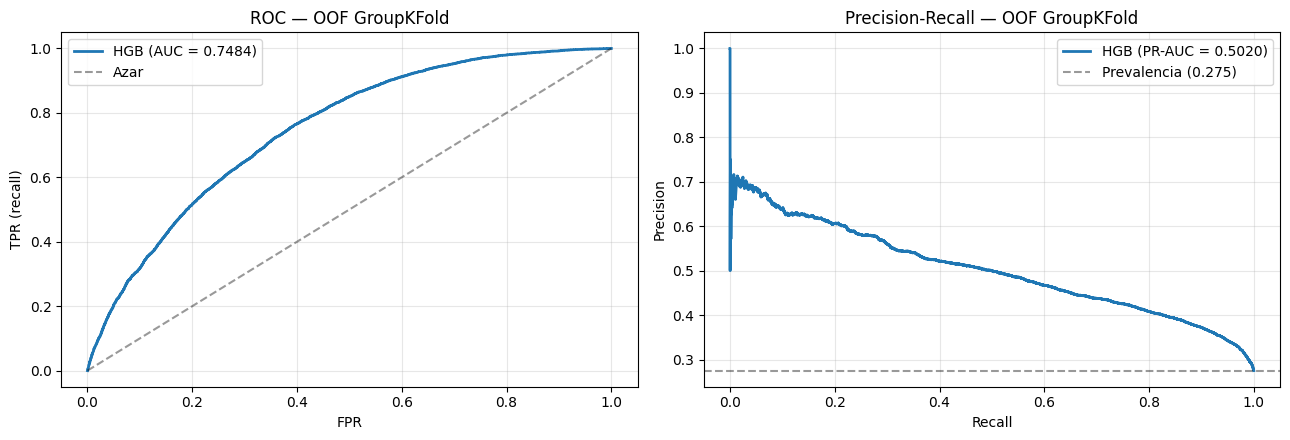

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fpr, tpr, _ = roc_curve(y, oof_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'HGB (AUC = {auc_oof:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Azar')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR (recall)')
axes[0].set_title('ROC — OOF GroupKFold')
axes[0].legend(); axes[0].grid(alpha=0.3)

p, r, _ = precision_recall_curve(y, oof_proba)
axes[1].plot(r, p, lw=2, label=f'HGB (PR-AUC = {ap_oof:.4f})')
axes[1].axhline(prev, ls='--', color='k', alpha=0.4, label=f'Prevalencia ({prev:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — OOF GroupKFold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


# 7. Validación 2: split temporal forward

`GroupKFold` mezcla épocas. Para simular el escenario real de producción
("entrenar con histórico, predecir mañana") usamos un split temporal:

- **Train** = todos los meses anteriores al corte.
- **Test** = últimos 6 meses.
- **GAP = 7 meses** entre el último mes de train y el primero de test:
  el target de la última fila de train mira los 6 meses siguientes; sin
  GAP, las features de test "saben" cosas que el target de train aún no
  terminaba de definir.

Una vendedora puede aparecer en train y en test (con observaciones de
meses distintos). Por eso esta métrica suele ser un poco más alta que la
de GroupKFold — no es sesgo, es otra pregunta: *"¿predigo bien el futuro
sabiendo que muchas vendedoras del test ya las vi antes?"*. Producción
se parece a este escenario.


In [11]:
last_rank  = int(df['mes_rank_obs'].max())
test_min   = last_rank - TEST_WINDOW + 1
train_max  = test_min - GAP

train_mask = df['mes_rank_obs'] <= train_max
test_mask  = df['mes_rank_obs'].between(test_min, last_rank)

df_train = df.loc[train_mask]
df_test  = df.loc[test_mask]

X_train = df_train[feature_cols]
y_train = df_train['churn'].astype(int).values
X_test  = df_test[feature_cols]
y_test  = df_test['churn'].astype(int).values

print(f'Train: mes_rank ≤ {train_max}  ·  {len(df_train):,} filas  ·  '
      f'{df_train["id_vendedor"].nunique():,} vendedoras  ·  '
      f'{df_train["mes_obs"].min()} → {df_train["mes_obs"].max()}')
print(f'GAP de {GAP} meses')
print(f'Test : mes_rank ∈ [{test_min}, {last_rank}]  ·  {len(df_test):,} filas  ·  '
      f'{df_test["id_vendedor"].nunique():,} vendedoras  ·  '
      f'{df_test["mes_obs"].min()} → {df_test["mes_obs"].max()}')


Train: mes_rank ≤ 96  ·  21,375 filas  ·  3,996 vendedoras  ·  2017-01-01 → 2024-10-01
GAP de 7 meses
Test : mes_rank ∈ [103, 108]  ·  1,061 filas  ·  556 vendedoras  ·  2025-05-01 → 2025-10-01


In [12]:
model_fwd = make_hgb()
model_fwd.fit(X_train, y_train)
proba_test = model_fwd.predict_proba(X_test)[:, 1]

auc_fwd  = roc_auc_score(y_test, proba_test)
ap_fwd   = average_precision_score(y_test, proba_test)
prev_fwd = y_test.mean()

# Estabilidad mes a mes
eval_df = df_test[['mes_rank_obs', 'mes_obs', 'churn']].copy()
eval_df['proba'] = proba_test
per_mes = []
for r, g in eval_df.groupby('mes_rank_obs'):
    yt = g['churn'].astype(int).values; pp = g['proba'].values
    n_pos = int(yt.sum())
    auc_v = roc_auc_score(yt, pp) if 0 < n_pos < len(yt) else np.nan
    per_mes.append({'mes': str(g['mes_obs'].iloc[0])[:7], 'n': len(yt),
                    'churn_rate': float(yt.mean()), 'AUC': auc_v})
per_mes = pd.DataFrame(per_mes)
auc_std_mes = per_mes['AUC'].std()

print(f'AUC bloque test     : {auc_fwd:.4f}')
print(f'PR-AUC bloque test  : {ap_fwd:.4f}   (prev {prev_fwd:.4f}, lift {ap_fwd/prev_fwd:.2f}×)')
print(f'AUC mes a mes       : media {per_mes["AUC"].mean():.4f}  ·  std {auc_std_mes:.4f}  ·  '
      f'min {per_mes["AUC"].min():.4f}  ·  max {per_mes["AUC"].max():.4f}')
print()
print(per_mes.round(4).to_string(index=False))


AUC bloque test     : 0.7537
PR-AUC bloque test  : 0.4846   (prev 0.2554, lift 1.90×)
AUC mes a mes       : media 0.7556  ·  std 0.0303  ·  min 0.7285  ·  max 0.8092

    mes   n  churn_rate    AUC
2025-05 185      0.2811 0.7285
2025-06 187      0.2781 0.7681
2025-07 155      0.2516 0.8092
2025-08 177      0.2373 0.7570
2025-09 182      0.2637 0.7365
2025-10 175      0.2171 0.7345


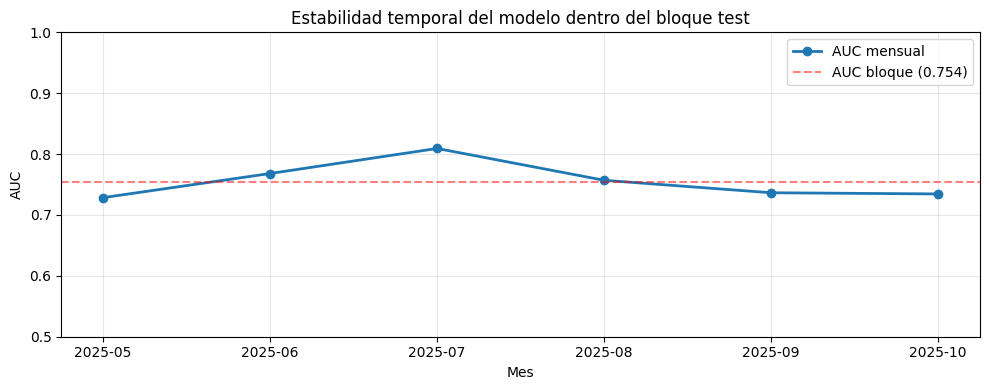

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(per_mes['mes'], per_mes['AUC'], marker='o', lw=2, label='AUC mensual')
ax.axhline(auc_fwd, ls='--', color='red', alpha=0.5, label=f'AUC bloque ({auc_fwd:.3f})')
ax.set_ylabel('AUC'); ax.set_xlabel('Mes')
ax.set_title('Estabilidad temporal del modelo dentro del bloque test')
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# 8. Threshold y matriz de confusión

AUC y PR-AUC no dependen del threshold. Para tomar decisiones operativas
(¿lanzo campaña?, ¿escalo a coordinadora?) hay que elegir un umbral. El
trade-off:

- **Threshold bajo (0.30)**: marcamos a muchos → alto recall, baja precision.
- **Threshold medio (0.50)**: equilibrio razonable.
- **Threshold alto (0.65)**: marcamos a pocos → alta precision, bajo recall.

No hay umbral universal: depende del costo relativo de FP vs FN. En
Glamour contactar es barato (mensaje WhatsApp/push) → conviene un
threshold que **maximice recall manteniendo un filtro real** sobre la
base.


In [14]:
def show_confusion(y_true, proba, threshold, label):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    n = tn + fp + fn + tp
    cm = pd.DataFrame([[tn, fp], [fn, tp]],
                      index=['real: no-churn', 'real: churn'],
                      columns=['pred: no-churn', 'pred: churn'])
    print(f'=== {label}  ·  threshold = {threshold}  ===')
    print(cm.to_string())
    print(f'  Accuracy {(tp+tn)/n:.4f}  ·  '
          f'Precision {tp/(tp+fp) if (tp+fp) else 0:.4f}  ·  '
          f'Recall {tp/(tp+fn) if (tp+fn) else 0:.4f}  ·  '
          f'F1 {f1_score(y_true, pred):.4f}')
    print()

show_confusion(y, oof_proba, 0.5, 'GroupKFold OOF')
show_confusion(y_test, proba_test, 0.5, 'Split forward bloque test')


=== GroupKFold OOF  ·  threshold = 0.5  ===
                pred: no-churn  pred: churn
real: no-churn           10816         6354
real: churn               1739         4775
  Accuracy 0.6583  ·  Precision 0.4291  ·  Recall 0.7330  ·  F1 0.5413

=== Split forward bloque test  ·  threshold = 0.5  ===
                pred: no-churn  pred: churn
real: no-churn             499          291
real: churn                 68          203
  Accuracy 0.6616  ·  Precision 0.4109  ·  Recall 0.7491  ·  F1 0.5307



**Barrido de threshold**: tabla y curvas para que negocio elija el punto
operativo según su tolerancia a falsos positivos.


In [15]:
def threshold_sweep(y_true, proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        rows.append({'threshold': round(float(t), 2),
                     'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
                     'precision': prec, 'recall': rec, 'F1': f1})
    return pd.DataFrame(rows)

sweep_oof = threshold_sweep(y, oof_proba)
print('Barrido de threshold — OOF GroupKFold')
print(sweep_oof.round(4).to_string(index=False))

best_idx = sweep_oof['F1'].idxmax()
print(f"\nThreshold que maximiza F1: {sweep_oof.loc[best_idx, 'threshold']}  "
      f"(F1 = {sweep_oof.loc[best_idx, 'F1']:.4f}, "
      f"precision = {sweep_oof.loc[best_idx, 'precision']:.4f}, "
      f"recall = {sweep_oof.loc[best_idx, 'recall']:.4f})")


Barrido de threshold — OOF GroupKFold
 threshold   TP    FP   FN    TN  precision  recall     F1
      0.10 6444 14959   70  2211     0.3011  0.9893 0.4617
      0.15 6387 13790  127  3380     0.3165  0.9805 0.4786
      0.20 6305 12801  209  4369     0.3300  0.9679 0.4922
      0.25 6184 11846  330  5324     0.3430  0.9493 0.5039
      0.30 6045 10876  469  6294     0.3572  0.9280 0.5159
      0.35 5856  9860  658  7310     0.3726  0.8990 0.5269
      0.40 5602  8794  912  8376     0.3891  0.8600 0.5358
      0.45 5235  7639 1279  9531     0.4066  0.8037 0.5400
      0.50 4775  6354 1739 10816     0.4291  0.7330 0.5413
      0.55 4197  5073 2317 12097     0.4528  0.6443 0.5318
      0.60 3548  3751 2966 13419     0.4861  0.5447 0.5137
      0.65 2848  2681 3666 14489     0.5151  0.4372 0.4730
      0.70 2047  1692 4467 15478     0.5475  0.3142 0.3993
      0.75 1345   870 5169 16300     0.6072  0.2065 0.3082
      0.80  619   346 5895 16824     0.6415  0.0950 0.1655
      0.85  161   

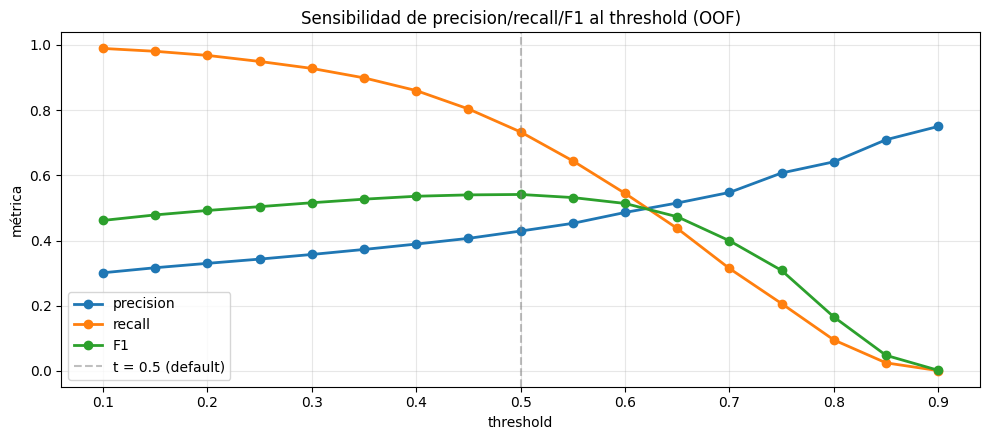

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, color in [('precision', 'tab:blue'), ('recall', 'tab:orange'), ('F1', 'tab:green')]:
    ax.plot(sweep_oof['threshold'], sweep_oof[col], marker='o', lw=2, label=col, color=color)
ax.axvline(0.5, ls='--', color='gray', alpha=0.5, label='t = 0.5 (default)')
ax.set_xlabel('threshold'); ax.set_ylabel('métrica')
ax.set_title('Sensibilidad de precision/recall/F1 al threshold (OOF)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# 9. Interpretabilidad: importancia por permutación

> **Idea**: medir cuánto cae el AUC si **mezclamos al azar** los valores
> de una feature, manteniendo todo lo demás igual. Si la métrica se
> derrumba, esa feature era importante; si no cambia, era irrelevante.

Es agnóstica al modelo y mide **impacto sobre la métrica** (no sólo "uso
interno"). La corremos sobre una muestra de 10K filas para que termine en
1–3 minutos.


In [17]:
model_full = make_hgb()
model_full.fit(X, y)

sample_size = min(10_000, len(X))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)

print(f'Calculando permutation_importance sobre {sample_size:,} filas...')
perm = permutation_importance(
    model_full, X.iloc[sample_idx], y[sample_idx],
    scoring='roc_auc', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)

imp = pd.DataFrame({
    'feature':         feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print('\nTop 20 features por permutación (caída de AUC al permutar):')
print(imp.head(20).round(4).to_string(index=False))


Calculando permutation_importance sobre 10,000 filas...

Top 20 features por permutación (caída de AUC al permutar):
                  feature  importance_mean  importance_std
       compras_historicas           0.0178          0.0008
         antiguedad_meses           0.0075          0.0006
          num_pedidos_obs           0.0070          0.0007
          num_compras_u12           0.0069          0.0013
                provincia           0.0051          0.0004
         ticket_u3_vs_u12           0.0044          0.0002
         monto_pagado_u12           0.0043          0.0015
           ratio_pago_u12           0.0042          0.0004
             departamento           0.0041          0.0002
            edad_vendedor           0.0040          0.0005
      ticket_promedio_u12           0.0038          0.0004
            ratio_pago_u3           0.0033          0.0004
          monto_historico           0.0032          0.0006
          monto_total_obs           0.0032          0.000

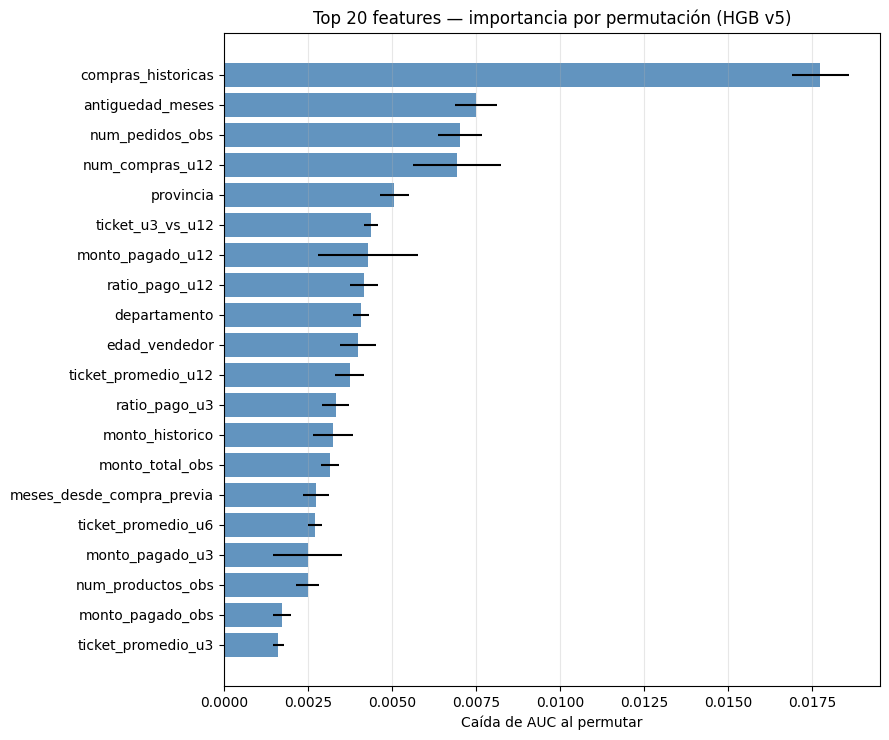

In [18]:
top_n = 20
top_imp = imp.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7.5))
ax.barh(top_imp['feature'], top_imp['importance_mean'],
        xerr=top_imp['importance_std'], color='steelblue', alpha=0.85)
ax.set_xlabel('Caída de AUC al permutar')
ax.set_title(f'Top {top_n} features — importancia por permutación (HGB v5)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


**Lectura del ranking**:

1. **La exposición domina**: `compras_historicas`, `antiguedad_meses`. El
   modelo se apoya en *cuán establecida es la vendedora* más que en su
   patrón reciente.
2. **Recencia explícita ausente del top 20**: contraintuitivo respecto de
   la heurística RFM. Hipótesis: la señal de recencia ya está embebida en
   `ratio_pago_u3`, `monto_total_u3`, etc. (un proxy de "compró poco hace
   poco"). Otra: con el filtro `compras_historicas >= 3` la varianza de
   la recencia se achica.
3. **Features RFM por ventana sí están**: `ratio_pago_*`, `monto_total_*`,
   `ticket_u3_vs_u12` aportan, sólo con menos peso del esperado.
4. **Sin features de calendario**: `mes_num` y `anio_mes_num` se sacaron
   tras el ablation (`ablation_temporal_v5.ipynb`).


# 10. Viabilidad de negocio

Esta sección responde la pregunta operativa: **¿deberíamos desplegar
esto?** Lo justifica con tres lentes complementarios: lift por decil,
puntos de operación, y casos de uso concretos.


## 10.1 Lift por decil

Ordenamos a las vendedoras de mayor a menor probabilidad de churn según
el modelo y dividimos en 10 grupos del mismo tamaño. En cada decil
medimos la fracción real de churners.

> **Lift del decil k** = (tasa de churn en ese decil) / (tasa global).
> Lift > 1 en los deciles altos = el modelo prioriza correctamente.


In [19]:
def lift_table(y_true, proba, n_bins=10):
    order = np.argsort(-proba)
    y_sorted = y_true[order]
    chunks = np.array_split(y_sorted, n_bins)
    base_rate = y_true.mean()
    total_pos = int(y_true.sum())
    rows, cum_pos, cum_n = [], 0, 0
    for i, ch in enumerate(chunks, 1):
        n = len(ch); n_pos = int(ch.sum())
        cum_pos += n_pos; cum_n += n
        rows.append({
            'decil': i, 'n_filas': n, 'n_churn': n_pos,
            'churn_rate': n_pos / n,
            'lift': (n_pos / n) / base_rate,
            'recall_acumulado': cum_pos / total_pos,
            '%_pob_acumulado':  cum_n / len(y_true),
        })
    return pd.DataFrame(rows)

lift_oof = lift_table(y, oof_proba)
print(f'Lift por decil — OOF GroupKFold (tasa global = {y.mean():.4f})')
print(lift_oof.round(4).to_string(index=False))


Lift por decil — OOF GroupKFold (tasa global = 0.2750)
 decil  n_filas  n_churn  churn_rate   lift  recall_acumulado  %_pob_acumulado
     1     2369     1423      0.6007 2.1840            0.2185           0.1000
     2     2369     1066      0.4500 1.6361            0.3821           0.2001
     3     2369      989      0.4175 1.5179            0.5339           0.3001
     4     2369      779      0.3288 1.1956            0.6535           0.4001
     5     2368      729      0.3079 1.1193            0.7654           0.5001
     6     2368      572      0.2416 0.8783            0.8532           0.6001
     7     2368      439      0.1854 0.6740            0.9206           0.7001
     8     2368      296      0.1250 0.4545            0.9661           0.8000
     9     2368      148      0.0625 0.2272            0.9888           0.9000
    10     2368       73      0.0308 0.1121            1.0000           1.0000


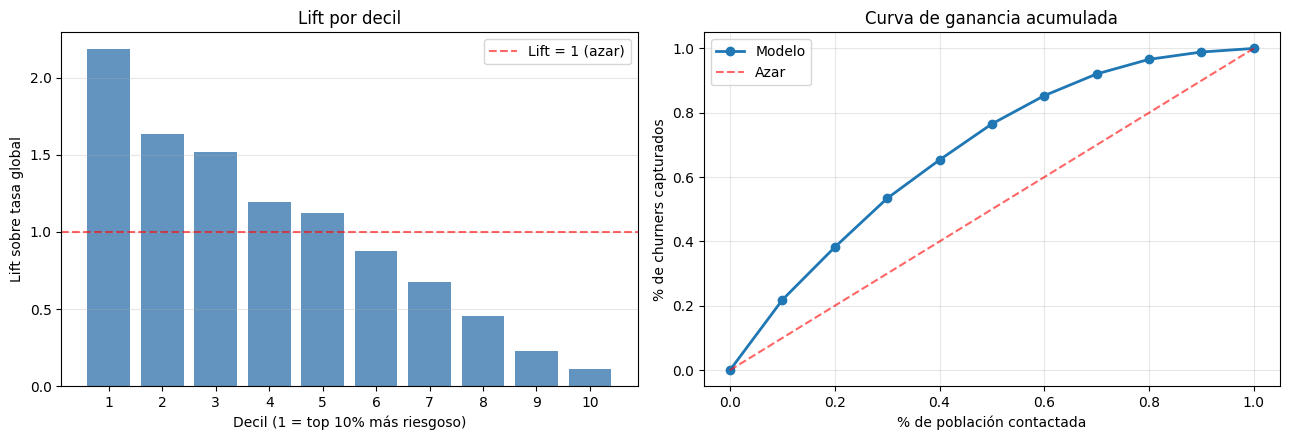

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(lift_oof['decil'], lift_oof['lift'], color='steelblue', alpha=0.85)
axes[0].axhline(1.0, ls='--', color='red', alpha=0.6, label='Lift = 1 (azar)')
axes[0].set_xlabel('Decil (1 = top 10% más riesgoso)')
axes[0].set_ylabel('Lift sobre tasa global')
axes[0].set_title('Lift por decil')
axes[0].set_xticks(range(1, 11)); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot([0] + list(lift_oof['%_pob_acumulado']),
             [0] + list(lift_oof['recall_acumulado']),
             marker='o', lw=2, label='Modelo')
axes[1].plot([0, 1], [0, 1], '--', color='red', alpha=0.6, label='Azar')
axes[1].set_xlabel('% de población contactada')
axes[1].set_ylabel('% de churners capturados')
axes[1].set_title('Curva de ganancia acumulada')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10.2 Tres puntos de operación

Cómo se mueven recall y precision según el threshold:


In [21]:
def operating_point(y_true, proba, threshold, label):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    base_rate = y_true.mean()
    return {
        'punto': label, 'threshold': threshold,
        '%_población': (tp + fp) / len(y_true),
        'recall':      tp / (tp + fn) if (tp + fn) else 0,
        'precision':   tp / (tp + fp) if (tp + fp) else 0,
        'lift_precision': (tp / (tp + fp) / base_rate) if (tp + fp) else 0,
        'F1':          f1_score(y_true, pred),
    }

points = pd.DataFrame([
    operating_point(y, oof_proba, 0.30, 'Agresivo  (t=0.30)'),
    operating_point(y, oof_proba, 0.50, 'Balanceado (t=0.50) ★'),
    operating_point(y, oof_proba, 0.65, 'Conservador (t=0.65)'),
])
print('Puntos de operación — OOF GroupKFold (sobre toda la base)')
print(points.round(4).to_string(index=False))
print(f'\n(prevalencia = {y.mean():.4f}; lift_precision = precision / prevalencia)')


Puntos de operación — OOF GroupKFold (sobre toda la base)
                punto  threshold  %_población  recall  precision  lift_precision     F1
   Agresivo  (t=0.30)       0.30       0.7144  0.9280     0.3572          1.2989 0.5159
Balanceado (t=0.50) ★       0.50       0.4699  0.7330     0.4291          1.5600 0.5413
 Conservador (t=0.65)       0.65       0.2334  0.4372     0.5151          1.8728 0.4730

(prevalencia = 0.2750; lift_precision = precision / prevalencia)


**Interpretación**:

- **Agresivo (t=0.30)** — descartado. Atrapamos al ~93% de los churners,
  pero contactando al **~71% de la base** con precision 0.36 (lift 1.30×).
  En la práctica es "contactar a casi todos" — el modelo aporta poco vs
  no usar modelo.
- **Balanceado (t=0.50) ★** — recomendado. Recall **0.73** (3 de 4),
  precision **0.43** (lift 1.56×). Tocamos al **~47% de la base**: filtro
  real. Es el punto que **maximiza F1** en el barrido de §8.
- **Conservador (t=0.65)** — descartado. Precision sube a 0.52 pero
  perdemos a más de la mitad de los churners (recall 0.44). Desperdicia
  la ventaja del régimen barato de contacto.


## 10.3 Casos de uso concretos

**A) Score mensual para priorizar la campaña de retención.**
Cada inicio de mes scorear a todas las vendedoras activas; lanzar la
campaña sólo sobre el top 20–30%. Si hoy se contacta al azar al 30% de
la base se atrapa al 30% de los churners; con el modelo, al mismo 30%
se atrapa ~60% — la efectividad **se duplica** sin tocar más vendedoras.

**B) Alerta semanal a coordinadora.**
Lista corta (5–10) de vendedoras con mayor riesgo por coordinadora; ella
decide la acción. Prioriza el tiempo escaso de la coordinadora hacia
donde más impacto tiene.

**C) Segmentación del portfolio.**
El score continuo se usa para segmentar (bajo / medio / alto / crítico) y
diseñar acciones diferenciadas. Útil para reportería ejecutiva ("¿cómo
está la salud del portfolio este mes?").

**D) Lo que el modelo NO debe hacer.** No decidir bajas automáticas. No
recortar comisión preventivamente (sería confundir predicción con
causalidad). No reemplazar el criterio de la coordinadora — lo enfoca,
no lo sustituye.


## 10.4 Limitaciones operativas

**Pipeline de datos**: el SQL `qry_churn_v5.sql` debe correr mensualmente
(hoy es manual; producción requiere job programado). Latencia mínima:
~3 días tras el cierre del mes.

**Reentrenamiento**: mensual o trimestral. Es barato (~30 segundos) y
previene drift silencioso. Trigger automático ante alertas: si la tasa
observada en el último mes se desvía ±5pp de la del anterior, gatillar
revisión.

**Monitoreo**: loggear score por (vendedora, mes) y comparar contra el
outcome a +6 meses. Dashboard de AUC rolling. Alertar si el AUC cae bajo
0.70 o si el recall a t=0.50 cae bajo 0.65.

**Calibración**: el modelo no está calibrado — `P(churn) = 0.7` no
significa "70% de probabilidad real". Importa poco mientras se opere por
threshold fijo; importaría si en el futuro se usaran las probabilidades
crudas para segmentación fina (aplicar `CalibratedClassifierCV`).

**Gobernanza**: documentar limitaciones en un *model card* visible para
los usuarios finales; auditar trimestralmente que el modelo no
discrimine geográficamente más allá de lo razonable.


## 10.5 Veredicto

**Sí, el modelo es viable en producción.** En el punto operativo
recomendado (t = 0.50):

| Métrica | Valor | Lectura de negocio |
|---|---:|---|
| **AUC split forward** | **0.75** | Ranquea bien al churner típico vs el no-churner típico el 75% de las veces. |
| **Recall** | **~73%** | Atrapamos a 3 de cada 4 churners reales. |
| **Precision** | **~43%** | 1.56× la prevalencia base. Filtro real, no ruido. |

> Sin modelo, contactando al 47% de la base al azar, atrapamos al 47%
> de los churners. **Con modelo, contactando al mismo 47%, atrapamos
> al 73%**. Esos 26 puntos extra de recall — sobre una base contactada
> menor que la mitad — son el valor incremental que aporta el sistema.

**Condiciones para desplegar**:

1. Pipeline mínimo en producción: job mensual que corra el SQL, genere
   scores y empuje la lista priorizada al equipo de retención.
2. Dashboard de monitoreo (AUC rolling + recall mes a mes), con alerta
   si caen bajo umbrales.
3. Reentrenamiento mensual o trimestral.
4. Uso correcto: el modelo **enfoca** la campaña, no decide bajas, no
   recorta comisiones.

**Lo que falta para subir el techo** (no son requisitos para desplegar):

- Atributos historizados (SCD-2) en lugar de snapshots actuales.
- Variables de comportamiento ausentes (interacciones con la app,
  asistencia a eventos, devoluciones).
- Definición de churn como tiempo-hasta-evento (modelo de supervivencia)
  en lugar de binario.


# 11. Resumen


In [22]:
print('=' * 70)
print('MODELO FINAL — silent churn Glamour Perú (dataset v5)')
print('=' * 70)
print()
print(f'Configuración')
print(f'  Granularidad         : (vendedora, mes)')
print(f'  Horizonte            : {HORIZON_CHURN} meses (justificado en §3)')
print(f'  Filtro de población  : compras_historicas >= 3')
print(f'  Modelo               : HistGradientBoosting (class_weight=balanced, tuneado)')
print()
print(f'GroupKFold por vendedora (5 folds)')
print(f'  AUC fold (mean ± std): {auc_mean:.4f} ± {auc_std:.4f}')
print(f'  AUC OOF concatenado  : {auc_oof:.4f}')
print(f'  PR-AUC OOF           : {ap_oof:.4f}   (lift {ap_oof/prev:.2f}×)')
print()
print(f'Split temporal forward (último bloque de {TEST_WINDOW} meses, GAP = {GAP})')
print(f'  AUC bloque test      : {auc_fwd:.4f}')
print(f'  PR-AUC bloque test   : {ap_fwd:.4f}   (lift {ap_fwd/prev_fwd:.2f}×)')
print(f'  Std AUC mes a mes    : {auc_std_mes:.4f}')
print()
print(f'Punto operativo recomendado: t = 0.50')
f1_default = f1_score(y, (oof_proba >= 0.5).astype(int))
print(f'  F1 a t=0.50          : {f1_default:.4f}  (OOF)')
print(f'  F1 óptimo            : {sweep_oof["F1"].max():.4f}  '
      f'a t = {sweep_oof.loc[sweep_oof["F1"].idxmax(), "threshold"]}')


MODELO FINAL — silent churn Glamour Perú (dataset v5)

Configuración
  Granularidad         : (vendedora, mes)
  Horizonte            : 6 meses (justificado en §3)
  Filtro de población  : compras_historicas >= 3
  Modelo               : HistGradientBoosting (class_weight=balanced, tuneado)

GroupKFold por vendedora (5 folds)
  AUC fold (mean ± std): 0.7485 ± 0.0082
  AUC OOF concatenado  : 0.7484
  PR-AUC OOF           : 0.5020   (lift 1.83×)

Split temporal forward (último bloque de 6 meses, GAP = 7)
  AUC bloque test      : 0.7537
  PR-AUC bloque test   : 0.4846   (lift 1.90×)
  Std AUC mes a mes    : 0.0303

Punto operativo recomendado: t = 0.50
  F1 a t=0.50          : 0.5413  (OOF)
  F1 óptimo            : 0.5413  a t = 0.5


---

*Notebook generado por `scripts/build_nb_modelo_final.py`. Para regenerar:*

```bash
uv run python scripts/build_nb_modelo_final.py
```

*No editar el `.ipynb` a mano — los cambios se pierden en la próxima
regeneración. Editá el script.*
